In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

In [5]:
plt.style.use('default')
sns.set(font_scale=0.9)

In [6]:
df = pd.read_csv("ObesityDataSet_raw_and_data_sinthetic.csv")

In [7]:
print(df.shape)

(2111, 17)


In [8]:
df.head()

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   object 
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   object 
 5   FAVC                            2111 non-null   object 
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   object 
 9   SMOKE                           2111 non-null   object 
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   object 
 12  FAF                             21

In [10]:
df.describe()

,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
count,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000
mean,24.312600,1.701677,86.586058,2.419043,2.685628,2.008011,1.010298,0.657866
std,6.345968,0.093305,26.191172,0.533927,0.778039,0.612953,0.850592,0.608927
min,14.000000,1.450000,39.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,19.947192,1.630000,65.473343,2.000000,2.658738,1.584812,0.124505,0.000000
50%,22.777890,1.700499,83.000000,2.385502,3.000000,2.000000,1.000000,0.625350
75%,26.000000,1.768464,107.430682,3.000000,3.000000,2.477420,1.666678,1.000000
max,61.000000,1.980000,173.000000,3.000000,4.000000,3.000000,3.000000,2.000000


In [11]:
print("\nTarget distribution (NObeyesdad):")
print(df['NObeyesdad'].value_counts())


Target distribution (NObeyesdad):
NObeyesdad
Obesity_Type_I         351
Obesity_Type_III       324
Obesity_Type_II        297
Overweight_Level_I     290
Overweight_Level_II    290
Normal_Weight          287
Insufficient_Weight    272
Name: count, dtype: int64


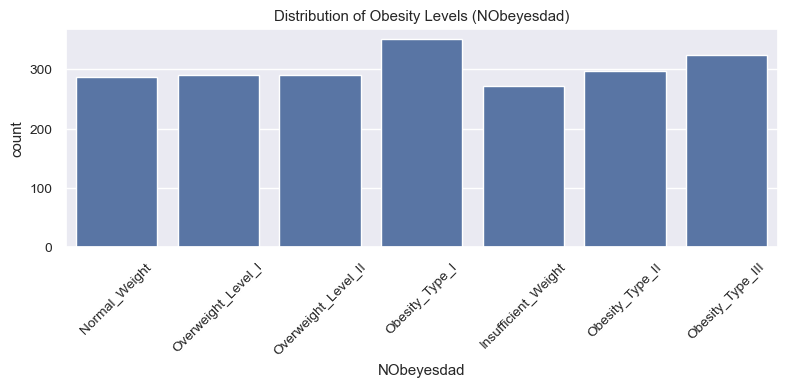

In [12]:
plt.figure(figsize=(8, 4))
sns.countplot(x='NObeyesdad', data=df)
plt.xticks(rotation=45)
plt.title("Distribution of Obesity Levels (NObeyesdad)")
plt.tight_layout()
plt.show()

In [13]:
num_cols = ['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']

In [14]:
df[num_cols].describe()

,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
count,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000
mean,24.312600,1.701677,86.586058,2.419043,2.685628,2.008011,1.010298,0.657866
std,6.345968,0.093305,26.191172,0.533927,0.778039,0.612953,0.850592,0.608927
min,14.000000,1.450000,39.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,19.947192,1.630000,65.473343,2.000000,2.658738,1.584812,0.124505,0.000000
50%,22.777890,1.700499,83.000000,2.385502,3.000000,2.000000,1.000000,0.625350
75%,26.000000,1.768464,107.430682,3.000000,3.000000,2.477420,1.666678,1.000000
max,61.000000,1.980000,173.000000,3.000000,4.000000,3.000000,3.000000,2.000000


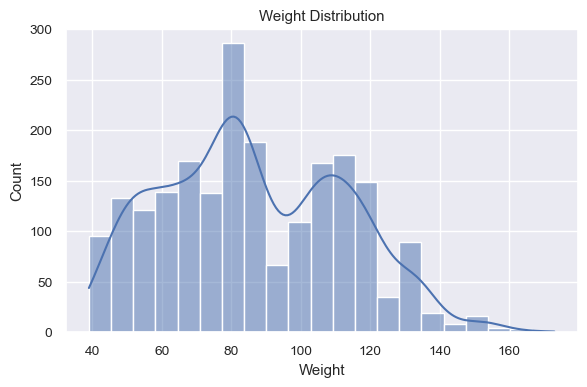

In [15]:
plt.figure(figsize=(6,4))
sns.histplot(df['Weight'], kde=True)
plt.title("Weight Distribution")
plt.tight_layout()
plt.show()

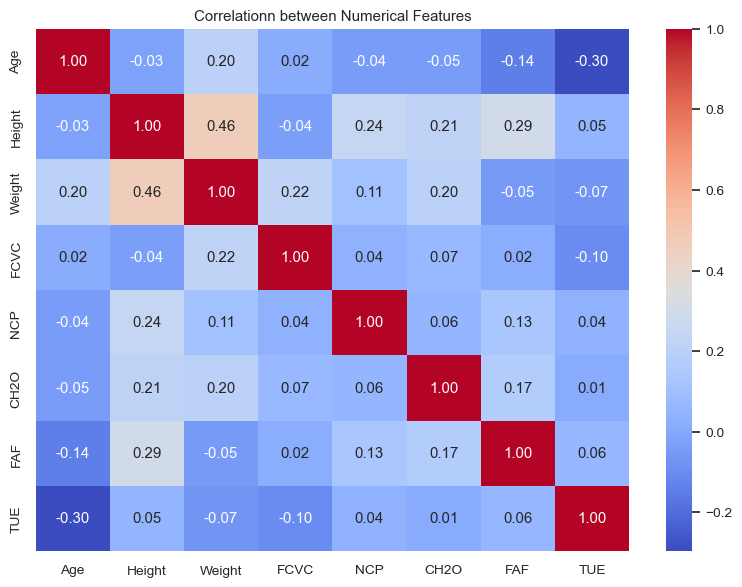

In [16]:
plt.figure(figsize= (8,6))
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Correlationn between Numerical Features")
plt.tight_layout()
plt.show()

In [17]:
ct_gender = pd.crosstab(df['Gender'], df['NObeyesdad'], normalize='index')
print("\nProportion of obesity levels by Gender:")
print(ct_gender)


Proportion of obesity levels by Gender:
NObeyesdad  Insufficient_Weight  Normal_Weight  Obesity_Type_I  \
Gender                                                           
Female                 0.165868       0.135187        0.149569   
Male                   0.092697       0.136704        0.182584   

NObeyesdad  Obesity_Type_II  Obesity_Type_III  Overweight_Level_I  \
Gender                                                              
Female             0.001918          0.309684            0.139022   
Male               0.276217          0.000936            0.135768   

NObeyesdad  Overweight_Level_II  
Gender                           
Female                 0.098754  
Male                   0.175094  


In [19]:
target_col = 'NObeyesdad' 
X = df.drop(columns =[target_col])
y = df[target_col]

In [20]:
cat_cols = [
    'Gender',
    'family_history_with_overweight',
    'FAVC',
    'CAEC',
    'SMOKE',
    'SCC',
    'CALC',
    'MTRANS']

In [21]:
X_encoded = pd.get_dummies(X, columns=cat_cols, drop_first=True)

In [22]:
print("\nEncoded feature columns:")
print(X_encoded.columns)


Encoded feature columns:
Index(['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE',
       'Gender_Male', 'family_history_with_overweight_yes', 'FAVC_yes',
       'CAEC_Frequently', 'CAEC_Sometimes', 'CAEC_no', 'SMOKE_yes', 'SCC_yes',
       'CALC_Frequently', 'CALC_Sometimes', 'CALC_no', 'MTRANS_Bike',
       'MTRANS_Motorbike', 'MTRANS_Public_Transportation', 'MTRANS_Walking'],
      dtype='object')


In [23]:
le = LabelEncoder()
y_encoded = le.fit_transform(y)

In [24]:
print("\nClasses in target (in encoded order):")
print(list(zip(le.classes_, range(len(le.classes_)))))


Classes in target (in encoded order):
[('Insufficient_Weight', 0), ('Normal_Weight', 1), ('Obesity_Type_I', 2), ('Obesity_Type_II', 3), ('Obesity_Type_III', 4), ('Overweight_Level_I', 5), ('Overweight_Level_II', 6)]


In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y_encoded,
    test_size=0.30,
    random_state=42,
    stratify=y_encoded
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (1477, 23)
Test shape: (634, 23)


In [26]:
print(X_train.shape,X_test.shape)

(1477, 23) (634, 23)


In [27]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [29]:
class_names = le.classes_

In [30]:
k_values = [3, 5, 7, 9, 11]
knn_results = []

In [31]:
for k in k_values:
    knn_temp = KNeighborsClassifier(
        n_neighbors=k,
        metric='minkowski',
        p=2  # Euclidean distance
    )
    knn_temp.fit(X_train_scaled, y_train)
    y_val_pred = knn_temp.predict(X_test_scaled)

    acc = accuracy_score(y_test, y_val_pred)
    f1_macro = f1_score(y_test, y_val_pred, average='macro')

    knn_results.append((k, acc, f1_macro))

    print(f"k={k} --> Accuracy: {acc:.4f}, Macro F1: {f1_macro:.4f}")

k=3 --> Accuracy: 0.7666, Macro F1: 0.7545
k=5 --> Accuracy: 0.7713, Macro F1: 0.7605
k=7 --> Accuracy: 0.7555, Macro F1: 0.7418
k=9 --> Accuracy: 0.7461, Macro F1: 0.7309
k=11 --> Accuracy: 0.7413, Macro F1: 0.7266


In [32]:
best_k, best_acc, best_f1 = max(knn_results, key=lambda x: x[2])
print(f"\nBest k based on Macro F1: k={best_k}, Accuracy={best_acc:.4f}, Macro F1={best_f1:.4f}")


Best k based on Macro F1: k=5, Accuracy=0.7713, Macro F1=0.7605


In [33]:
knn_clf = KNeighborsClassifier(
    n_neighbors=best_k,
    metric='minkowski',
    p=2
)

In [34]:
knn_clf.fit(X_train_scaled, y_train)
y_pred_knn = knn_clf.predict(X_test_scaled)

In [35]:
print("\n=== KNN FINAL MODEL - CLASSIFICATION REPORT ===")
print(classification_report(y_test, y_pred_knn, target_names=le.classes_))


=== KNN FINAL MODEL - CLASSIFICATION REPORT ===
                     precision    recall  f1-score   support

Insufficient_Weight       0.77      0.91      0.84        82
      Normal_Weight       0.52      0.45      0.48        86
     Obesity_Type_I       0.74      0.85      0.79       106
    Obesity_Type_II       0.86      0.91      0.89        89
   Obesity_Type_III       0.98      0.99      0.98        97
 Overweight_Level_I       0.69      0.59      0.63        87
Overweight_Level_II       0.77      0.66      0.71        87

           accuracy                           0.77       634
          macro avg       0.76      0.77      0.76       634
       weighted avg       0.76      0.77      0.77       634



In [36]:
knn_acc = accuracy_score(y_test, y_pred_knn)
knn_f1_macro = f1_score(y_test, y_pred_knn, average='macro')
knn_f1_weighted = f1_score(y_test, y_pred_knn, average='weighted')

print(f"KNN Accuracy: {knn_acc:.4f}")
print(f"KNN Macro F1: {knn_f1_macro:.4f}")
print(f"KNN Weighted F1: {knn_f1_weighted:.4f}")

KNN Accuracy: 0.7713
KNN Macro F1: 0.7605
KNN Weighted F1: 0.7651


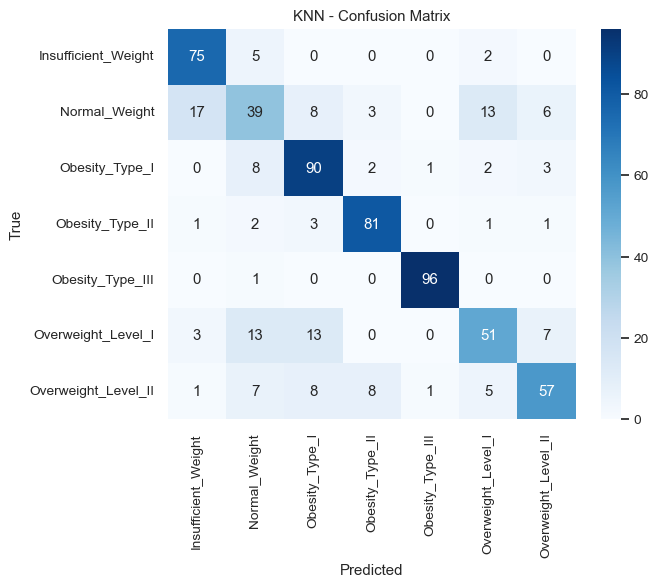

In [37]:
cm_knn = confusion_matrix(y_test, y_pred_knn)
plot_confusion_matrix(cm_knn, le.classes_, "KNN - Confusion Matrix")

In [50]:
dt_baseline = DecisionTreeClassifier(
    criterion='gini',   # or 'entropy'
    max_depth=None,     # you can try values like 5, 10, 15 to reduce overfitting
    min_samples_split=2,
    random_state=42
)

In [51]:
dt_baseline.fit(X_train, y_train)  # Decision Trees don't need scaled features
y_pred_dt = dt_baseline.predict(X_test)
print("\n=== DECISION TREE - CLASSIFICATION REPORT ===")
print(classification_report(y_test, y_pred_dt, target_names=le.classes_))


=== DECISION TREE - CLASSIFICATION REPORT ===
                     precision    recall  f1-score   support

Insufficient_Weight       0.94      0.90      0.92        82
      Normal_Weight       0.82      0.81      0.82        86
     Obesity_Type_I       0.89      0.95      0.92       106
    Obesity_Type_II       0.95      0.94      0.95        89
   Obesity_Type_III       1.00      0.99      0.99        97
 Overweight_Level_I       0.88      0.90      0.89        87
Overweight_Level_II       0.95      0.92      0.94        87

           accuracy                           0.92       634
          macro avg       0.92      0.92      0.92       634
       weighted avg       0.92      0.92      0.92       634



In [52]:
dt_acc = accuracy_score(y_test, y_pred_dt)
dt_f1_macro = f1_score(y_test, y_pred_dt, average='macro')
dt_f1_weighted = f1_score(y_test, y_pred_dt, average='weighted')

print(f"Decision Tree Accuracy: {dt_acc:.4f}")
print(f"Decision Tree Macro F1: {dt_f1_macro:.4f}")
print(f"Decision Tree Weighted F1: {dt_f1_weighted:.4f}")

Decision Tree Accuracy: 0.9196
Decision Tree Macro F1: 0.9180
Decision Tree Weighted F1: 0.9196


In [53]:
# 7.4 Decision Tree with class_weight='balanced'. initial overfitting experiment
dt_balanced = DecisionTreeClassifier(
    criterion='gini',
    max_depth=10,
    min_samples_split=2,
    class_weight='balanced',
    random_state=42
)

In [55]:
def evaluate_model(model_name, y_true, y_pred, class_names, show_report=True, show_cm=True):
    acc = accuracy_score(y_true, y_pred)
    f1_macro = f1_score(y_true, y_pred, average='macro')
    f1_weighted = f1_score(y_true, y_pred, average='weighted')

    print(f"\n=== {model_name} - METRICS ===")
    print(f"Accuracy     : {acc:.4f}")
    print(f"Macro F1     : {f1_macro:.4f}")
    print(f"Weighted F1  : {f1_weighted:.4f}")

    if show_report:
        print(f"\n=== {model_name} - CLASSIFICATION REPORT ===")
        print(classification_report(y_true, y_pred, target_names=class_names))

    if show_cm:
        cm = confusion_matrix(y_true, y_pred)
        plot_confusion_matrix(cm, class_names, f"{model_name} - Confusion Matrix")

    return acc, f1_macro, f1_weighted



=== Decision Tree (Balanced, max_depth=None) - METRICS ===
Accuracy     : 0.9243
Macro F1     : 0.9232
Weighted F1  : 0.9247

=== Decision Tree (Balanced, max_depth=None) - CLASSIFICATION REPORT ===
                     precision    recall  f1-score   support

Insufficient_Weight       0.97      0.91      0.94        82
      Normal_Weight       0.84      0.84      0.84        86
     Obesity_Type_I       0.90      0.96      0.93       106
    Obesity_Type_II       0.97      0.94      0.95        89
   Obesity_Type_III       1.00      0.99      0.99        97
 Overweight_Level_I       0.85      0.90      0.87        87
Overweight_Level_II       0.95      0.91      0.93        87

           accuracy                           0.92       634
          macro avg       0.93      0.92      0.92       634
       weighted avg       0.93      0.92      0.92       634



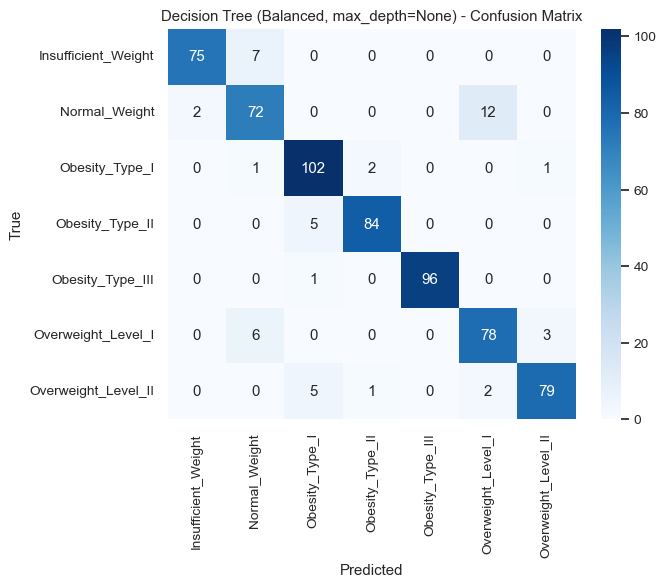

(0.9242902208201893, 0.9231995185778701, 0.9246533500853255)

In [56]:
evaluate_model("Decision Tree (Balanced, max_depth=None)", y_test, y_pred_dt_base, class_names)


=== Decision Tree (Balanced, max_depth=None) - TRAIN - METRICS ===
Accuracy     : 1.0000
Macro F1     : 1.0000
Weighted F1  : 1.0000

=== Decision Tree (Balanced, max_depth=None) - TRAIN - CLASSIFICATION REPORT ===
                     precision    recall  f1-score   support

Insufficient_Weight       1.00      1.00      1.00       190
      Normal_Weight       1.00      1.00      1.00       201
     Obesity_Type_I       1.00      1.00      1.00       245
    Obesity_Type_II       1.00      1.00      1.00       208
   Obesity_Type_III       1.00      1.00      1.00       227
 Overweight_Level_I       1.00      1.00      1.00       203
Overweight_Level_II       1.00      1.00      1.00       203

           accuracy                           1.00      1477
          macro avg       1.00      1.00      1.00      1477
       weighted avg       1.00      1.00      1.00      1477



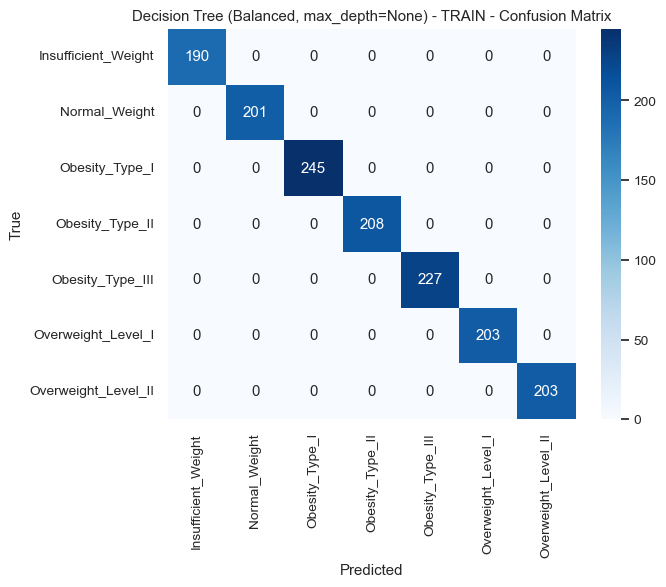

(1.0, 1.0, 1.0)

In [57]:
y_train_pred_dt_base = dt_baseline.predict(X_train)

evaluate_model(
    "Decision Tree (Balanced, max_depth=None) - TRAIN",
    y_train,
    y_train_pred_dt_base,
    class_names
)


=== Decision Tree (Balanced, max_depth=3) - TEST - METRICS ===
Accuracy     : 0.6625
Macro F1     : 0.6489
Weighted F1  : 0.6428

=== Decision Tree (Balanced, max_depth=3) - TEST - CLASSIFICATION REPORT ===
                     precision    recall  f1-score   support

Insufficient_Weight       0.91      0.62      0.74        82
      Normal_Weight       0.55      0.44      0.49        86
     Obesity_Type_I       0.80      0.15      0.25       106
    Obesity_Type_II       0.88      0.91      0.90        89
   Obesity_Type_III       1.00      0.99      0.99        97
 Overweight_Level_I       0.54      0.70      0.61        87
Overweight_Level_II       0.41      0.89      0.56        87

           accuracy                           0.66       634
          macro avg       0.73      0.67      0.65       634
       weighted avg       0.73      0.66      0.64       634



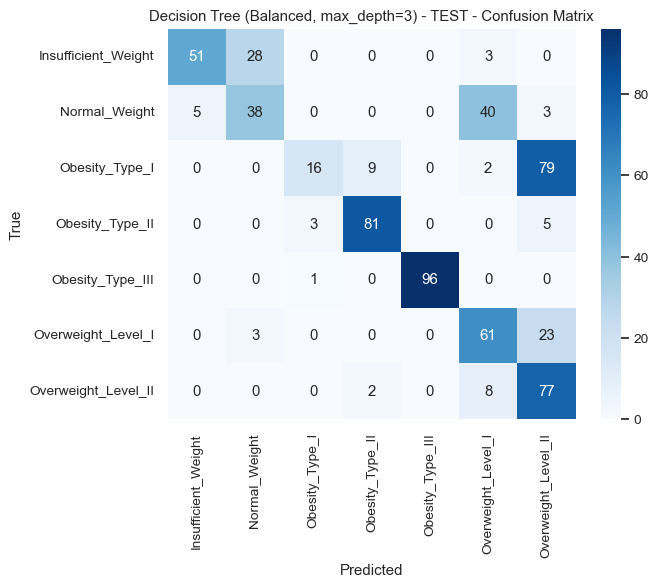


=== Decision Tree (Balanced, max_depth=5) - TEST - METRICS ===
Accuracy     : 0.8170
Macro F1     : 0.8158
Weighted F1  : 0.8181

=== Decision Tree (Balanced, max_depth=5) - TEST - CLASSIFICATION REPORT ===
                     precision    recall  f1-score   support

Insufficient_Weight       0.96      0.90      0.93        82
      Normal_Weight       0.86      0.63      0.72        86
     Obesity_Type_I       0.71      0.93      0.81       106
    Obesity_Type_II       1.00      0.91      0.95        89
   Obesity_Type_III       1.00      0.99      0.99        97
 Overweight_Level_I       0.72      0.67      0.69        87
Overweight_Level_II       0.58      0.64      0.61        87

           accuracy                           0.82       634
          macro avg       0.83      0.81      0.82       634
       weighted avg       0.83      0.82      0.82       634



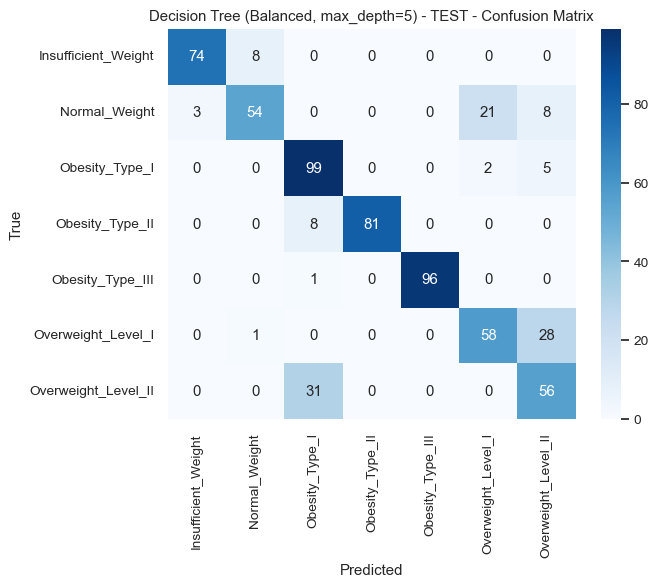


=== Decision Tree (Balanced, max_depth=7) - TEST - METRICS ===
Accuracy     : 0.8644
Macro F1     : 0.8611
Weighted F1  : 0.8642

=== Decision Tree (Balanced, max_depth=7) - TEST - CLASSIFICATION REPORT ===
                     precision    recall  f1-score   support

Insufficient_Weight       0.96      0.88      0.92        82
      Normal_Weight       0.77      0.71      0.74        86
     Obesity_Type_I       0.82      0.97      0.89       106
    Obesity_Type_II       0.99      0.94      0.97        89
   Obesity_Type_III       1.00      0.99      0.99        97
 Overweight_Level_I       0.71      0.76      0.73        87
Overweight_Level_II       0.81      0.76      0.79        87

           accuracy                           0.86       634
          macro avg       0.87      0.86      0.86       634
       weighted avg       0.87      0.86      0.86       634



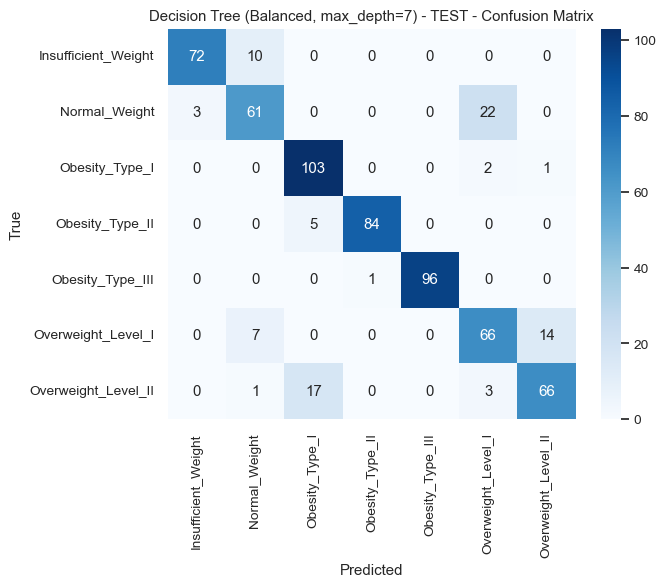


=== Decision Tree (Balanced, max_depth=9) - TEST - METRICS ===
Accuracy     : 0.9259
Macro F1     : 0.9248
Weighted F1  : 0.9263

=== Decision Tree (Balanced, max_depth=9) - TEST - CLASSIFICATION REPORT ===
                     precision    recall  f1-score   support

Insufficient_Weight       0.97      0.91      0.94        82
      Normal_Weight       0.83      0.85      0.84        86
     Obesity_Type_I       0.91      0.96      0.94       106
    Obesity_Type_II       0.97      0.94      0.95        89
   Obesity_Type_III       1.00      0.99      0.99        97
 Overweight_Level_I       0.86      0.89      0.87        87
Overweight_Level_II       0.95      0.92      0.94        87

           accuracy                           0.93       634
          macro avg       0.93      0.92      0.92       634
       weighted avg       0.93      0.93      0.93       634



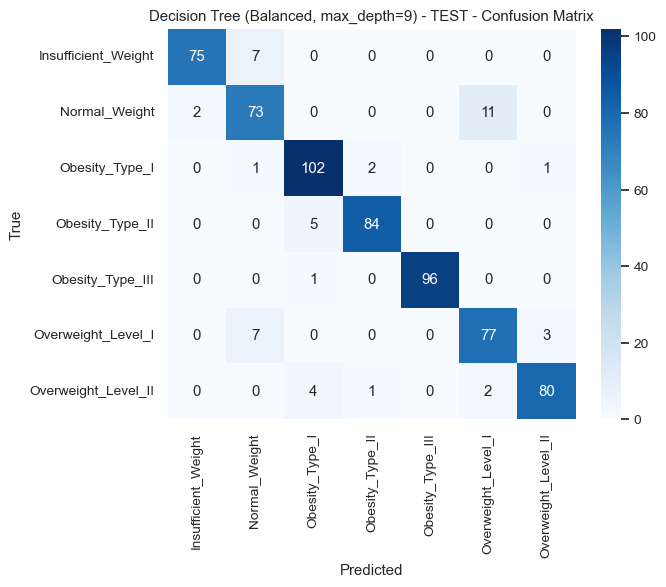


=== Decision Tree (Balanced, max_depth=10) - TEST - METRICS ===
Accuracy     : 0.9243
Macro F1     : 0.9232
Weighted F1  : 0.9247

=== Decision Tree (Balanced, max_depth=10) - TEST - CLASSIFICATION REPORT ===
                     precision    recall  f1-score   support

Insufficient_Weight       0.97      0.91      0.94        82
      Normal_Weight       0.84      0.84      0.84        86
     Obesity_Type_I       0.90      0.96      0.93       106
    Obesity_Type_II       0.97      0.94      0.95        89
   Obesity_Type_III       1.00      0.99      0.99        97
 Overweight_Level_I       0.85      0.90      0.87        87
Overweight_Level_II       0.95      0.91      0.93        87

           accuracy                           0.92       634
          macro avg       0.93      0.92      0.92       634
       weighted avg       0.93      0.92      0.92       634



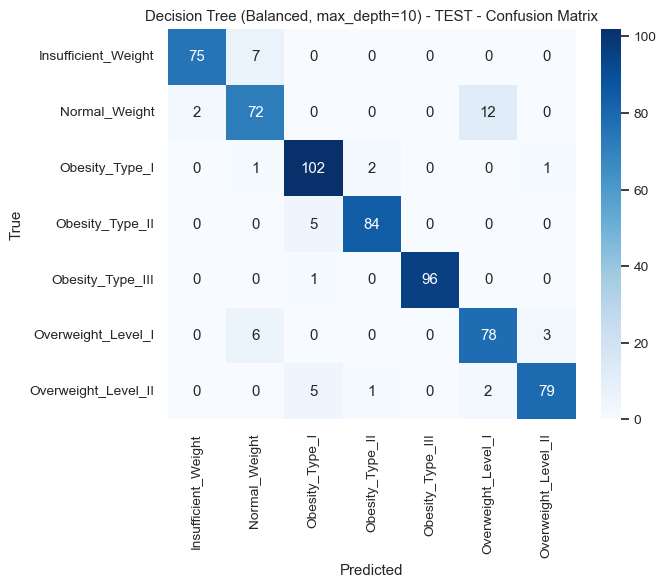


=== Decision Tree (Balanced, max_depth=12) - TEST - METRICS ===
Accuracy     : 0.9243
Macro F1     : 0.9233
Weighted F1  : 0.9246

=== Decision Tree (Balanced, max_depth=12) - TEST - CLASSIFICATION REPORT ===
                     precision    recall  f1-score   support

Insufficient_Weight       0.97      0.91      0.94        82
      Normal_Weight       0.85      0.84      0.84        86
     Obesity_Type_I       0.89      0.96      0.93       106
    Obesity_Type_II       0.97      0.94      0.95        89
   Obesity_Type_III       1.00      0.99      0.99        97
 Overweight_Level_I       0.85      0.91      0.88        87
Overweight_Level_II       0.95      0.90      0.92        87

           accuracy                           0.92       634
          macro avg       0.93      0.92      0.92       634
       weighted avg       0.93      0.92      0.92       634



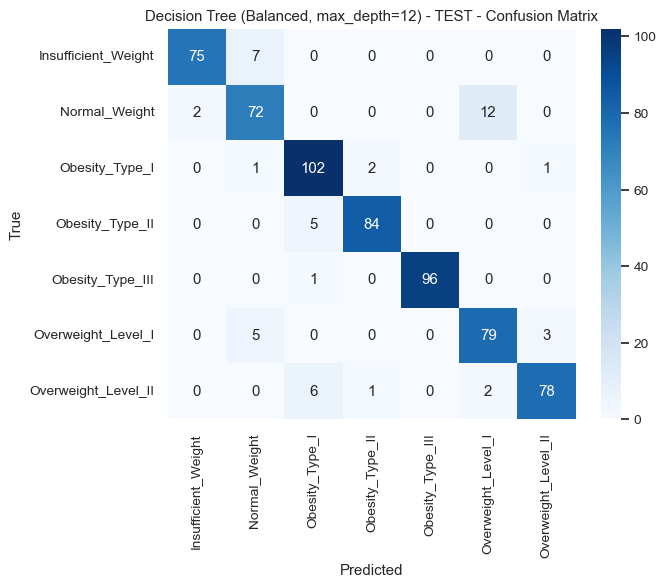


=== Decision Tree (Balanced, max_depth=15) - TEST - METRICS ===
Accuracy     : 0.9243
Macro F1     : 0.9233
Weighted F1  : 0.9246

=== Decision Tree (Balanced, max_depth=15) - TEST - CLASSIFICATION REPORT ===
                     precision    recall  f1-score   support

Insufficient_Weight       0.97      0.91      0.94        82
      Normal_Weight       0.85      0.84      0.84        86
     Obesity_Type_I       0.89      0.96      0.93       106
    Obesity_Type_II       0.97      0.94      0.95        89
   Obesity_Type_III       1.00      0.99      0.99        97
 Overweight_Level_I       0.85      0.91      0.88        87
Overweight_Level_II       0.95      0.90      0.92        87

           accuracy                           0.92       634
          macro avg       0.93      0.92      0.92       634
       weighted avg       0.93      0.92      0.92       634



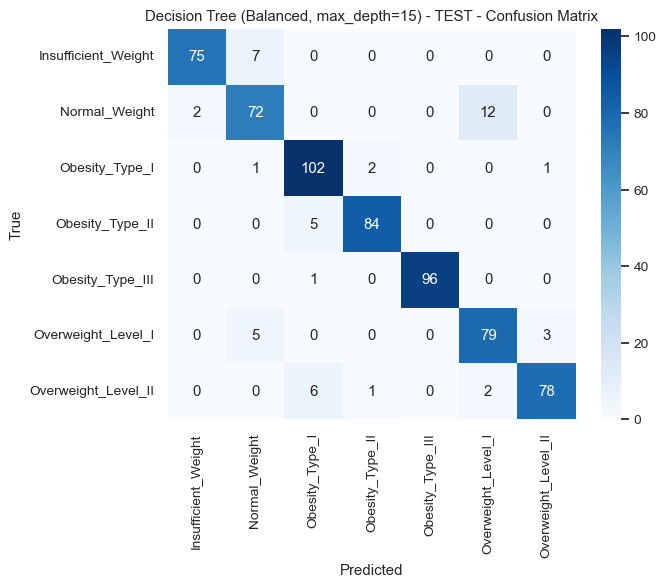


=== Decision Tree (Balanced, max_depth=None) - TEST - METRICS ===
Accuracy     : 0.9243
Macro F1     : 0.9233
Weighted F1  : 0.9246

=== Decision Tree (Balanced, max_depth=None) - TEST - CLASSIFICATION REPORT ===
                     precision    recall  f1-score   support

Insufficient_Weight       0.97      0.91      0.94        82
      Normal_Weight       0.85      0.84      0.84        86
     Obesity_Type_I       0.89      0.96      0.93       106
    Obesity_Type_II       0.97      0.94      0.95        89
   Obesity_Type_III       1.00      0.99      0.99        97
 Overweight_Level_I       0.85      0.91      0.88        87
Overweight_Level_II       0.95      0.90      0.92        87

           accuracy                           0.92       634
          macro avg       0.93      0.92      0.92       634
       weighted avg       0.93      0.92      0.92       634



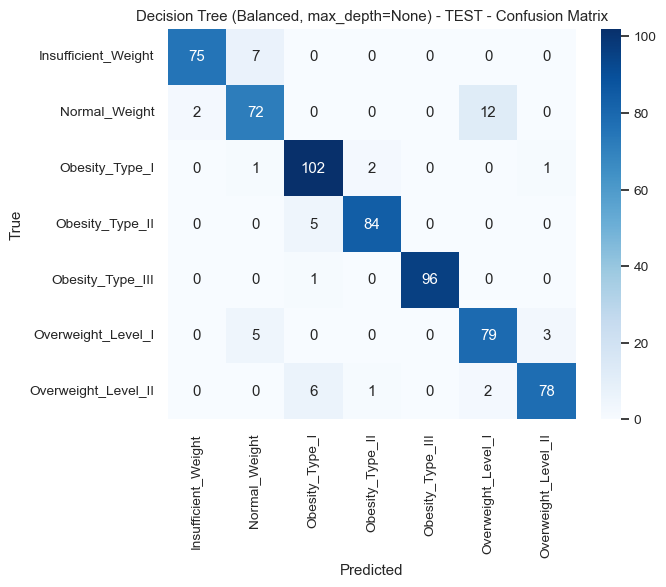


SUMMARY (TEST SET):
max_depth=3: Accuracy=0.6625, Macro F1=0.6489, Weighted F1=0.6428
max_depth=5: Accuracy=0.8170, Macro F1=0.8158, Weighted F1=0.8181
max_depth=7: Accuracy=0.8644, Macro F1=0.8611, Weighted F1=0.8642
max_depth=9: Accuracy=0.9259, Macro F1=0.9248, Weighted F1=0.9263
max_depth=10: Accuracy=0.9243, Macro F1=0.9232, Weighted F1=0.9247
max_depth=12: Accuracy=0.9243, Macro F1=0.9233, Weighted F1=0.9246
max_depth=15: Accuracy=0.9243, Macro F1=0.9233, Weighted F1=0.9246
max_depth=None: Accuracy=0.9243, Macro F1=0.9233, Weighted F1=0.9246


In [58]:
depth_values = [3, 5, 7, 9, 10, 12, 15, None]
dt_results = []

for d in depth_values:
    dt = DecisionTreeClassifier(
        criterion='gini',
        max_depth=d,
        class_weight='balanced',
        random_state=42
    )
    dt.fit(X_train, y_train)
    y_pred = dt.predict(X_test)

    acc, f1_macro, f1_weighted = evaluate_model(
        f"Decision Tree (Balanced, max_depth={d}) - TEST",
        y_test,
        y_pred,
        class_names
    )

    dt_results.append((d, acc, f1_macro, f1_weighted))

print("\nSUMMARY (TEST SET):")
for d, acc, f1m, f1w in dt_results:
    print(f"max_depth={d}: Accuracy={acc:.4f}, Macro F1={f1m:.4f}, Weighted F1={f1w:.4f}")

In [59]:
dt_final = DecisionTreeClassifier(
    criterion='gini',
    max_depth=9,
    class_weight='balanced',
    random_state=42
)

dt_final.fit(X_train, y_train)

DecisionTreeClassifier(class_weight='balanced', max_depth=9, random_state=42)


=== Decision Tree FINAL (max_depth=9) - TRAIN - METRICS ===
Accuracy     : 0.9926
Macro F1     : 0.9923
Weighted F1  : 0.9926

=== Decision Tree FINAL (max_depth=9) - TRAIN - CLASSIFICATION REPORT ===
                     precision    recall  f1-score   support

Insufficient_Weight       1.00      1.00      1.00       190
      Normal_Weight       0.98      0.98      0.98       201
     Obesity_Type_I       1.00      1.00      1.00       245
    Obesity_Type_II       1.00      1.00      1.00       208
   Obesity_Type_III       1.00      1.00      1.00       227
 Overweight_Level_I       0.98      0.98      0.98       203
Overweight_Level_II       0.99      1.00      0.99       203

           accuracy                           0.99      1477
          macro avg       0.99      0.99      0.99      1477
       weighted avg       0.99      0.99      0.99      1477



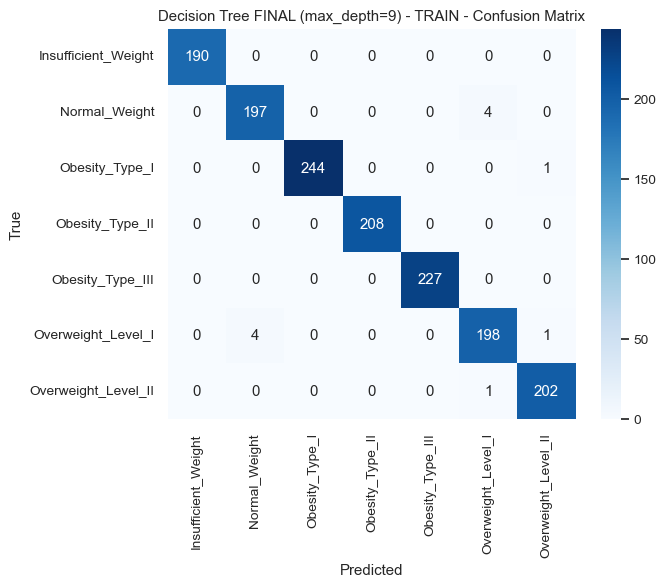

(0.992552471225457, 0.9922932804956547, 0.9925542742104253)

In [60]:
y_train_pred_dt_final = dt_final.predict(X_train)
evaluate_model(
    "Decision Tree FINAL (max_depth=9) - TRAIN",
    y_train,
    y_train_pred_dt_final,
    class_names
)


=== Decision Tree FINAL (max_depth=9) - TEST - METRICS ===
Accuracy     : 0.9259
Macro F1     : 0.9248
Weighted F1  : 0.9263

=== Decision Tree FINAL (max_depth=9) - TEST - CLASSIFICATION REPORT ===
                     precision    recall  f1-score   support

Insufficient_Weight       0.97      0.91      0.94        82
      Normal_Weight       0.83      0.85      0.84        86
     Obesity_Type_I       0.91      0.96      0.94       106
    Obesity_Type_II       0.97      0.94      0.95        89
   Obesity_Type_III       1.00      0.99      0.99        97
 Overweight_Level_I       0.86      0.89      0.87        87
Overweight_Level_II       0.95      0.92      0.94        87

           accuracy                           0.93       634
          macro avg       0.93      0.92      0.92       634
       weighted avg       0.93      0.93      0.93       634



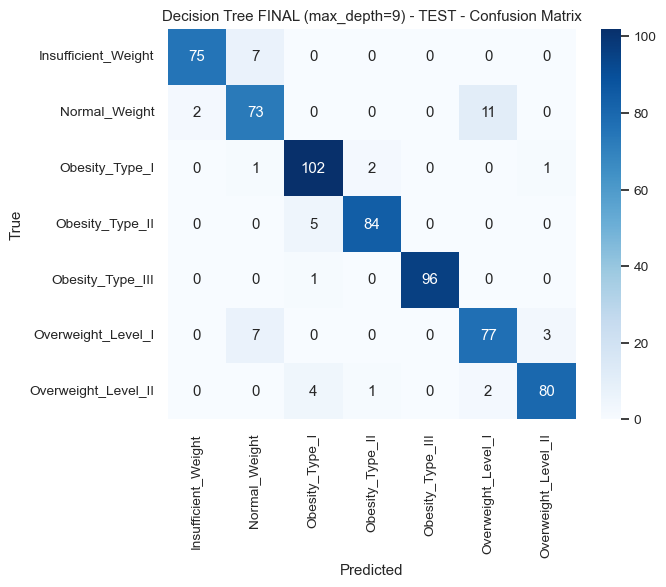

In [61]:
y_test_pred_dt_final = dt_final.predict(X_test)
dt_final_acc, dt_final_f1_macro, dt_final_f1_weighted = evaluate_model(
    "Decision Tree FINAL (max_depth=9) - TEST",
    y_test,
    y_test_pred_dt_final,
    class_names
)

            feature  importance
2            Weight    0.477379
1            Height    0.217155
8       Gender_Male    0.154474
0               Age    0.042562
10         FAVC_yes    0.027257
18          CALC_no    0.022207
7               TUE    0.015144
3              FCVC    0.013137
11  CAEC_Frequently    0.008281
4               NCP    0.004525


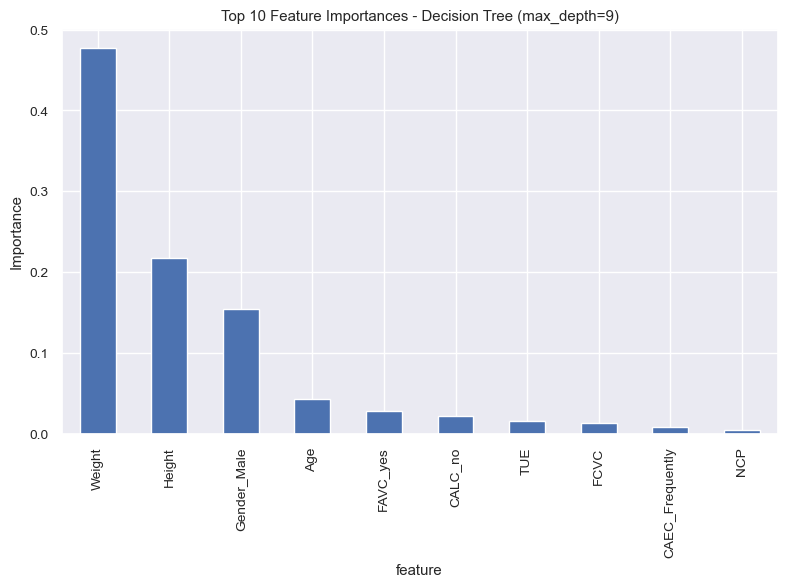

In [62]:
importances = dt_final.feature_importances_
feature_names = X_train.columns

feat_importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values(by='importance', ascending=False)

print(feat_importance_df.head(10))

plt.figure(figsize=(8, 6))
feat_importance_df.head(10).set_index('feature')['importance'].plot(kind='bar')
plt.title("Top 10 Feature Importances - Decision Tree (max_depth=9)")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()


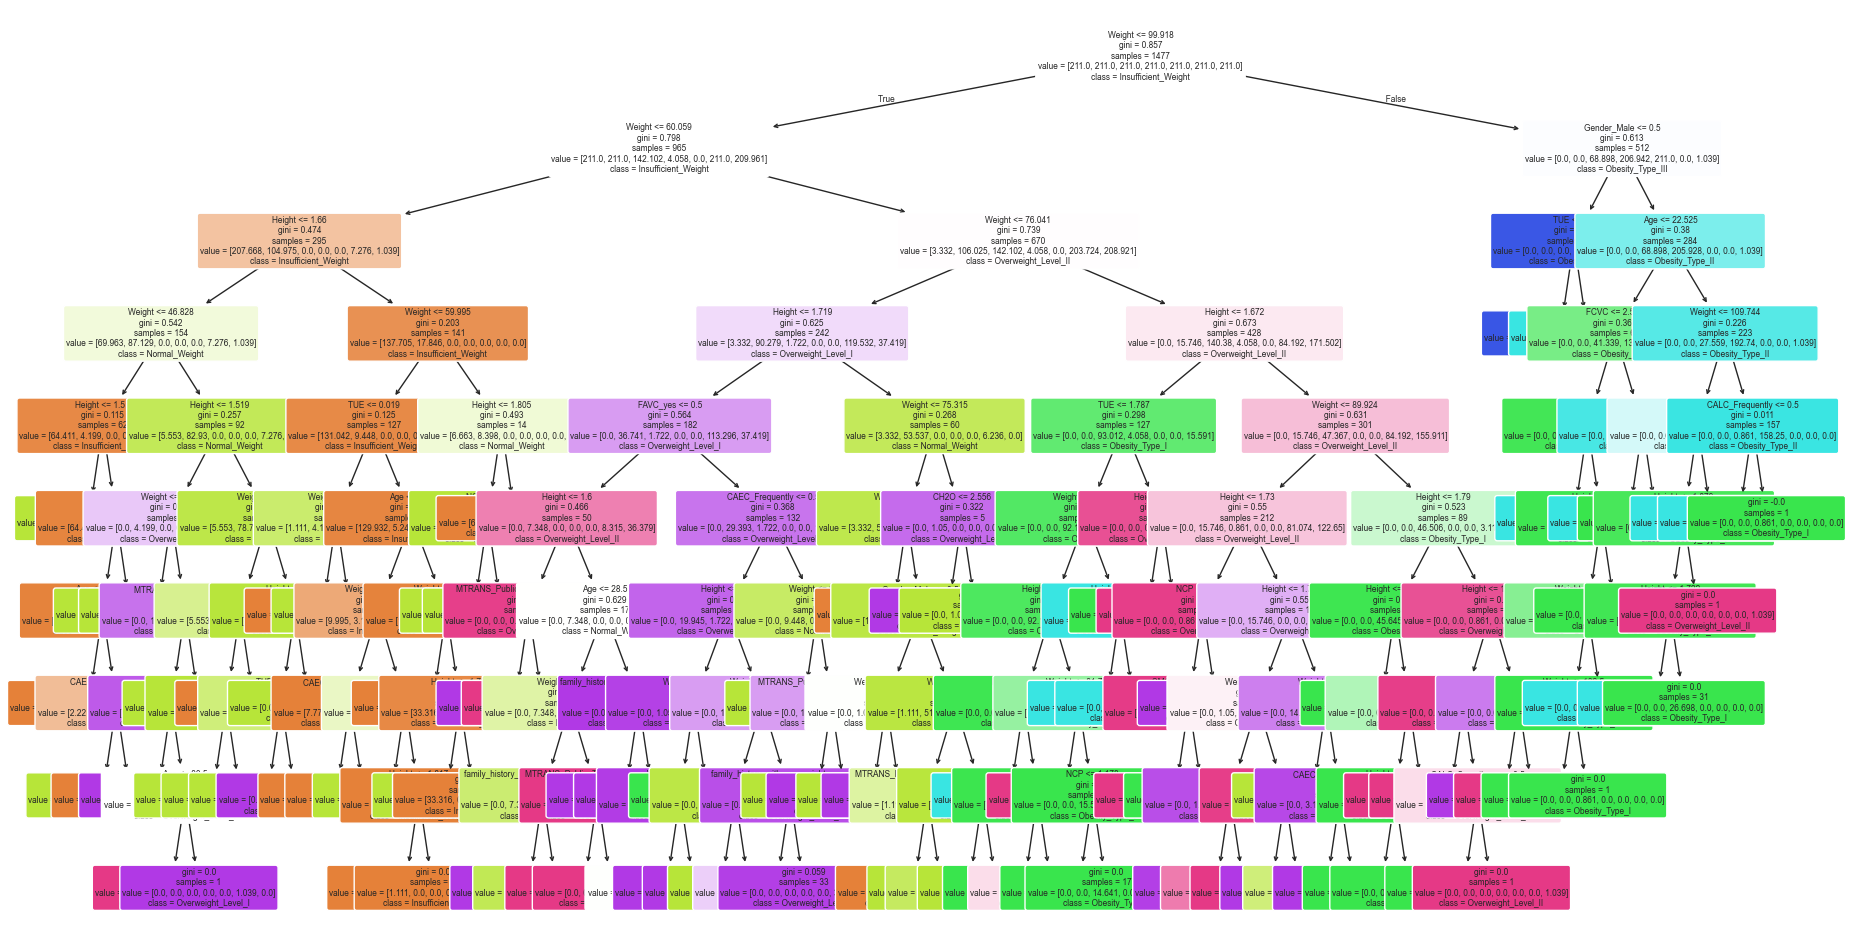

In [63]:
from sklearn import tree
plt.figure(figsize=(22, 12))
tree.plot_tree(
    dt_final,
    feature_names=X_train.columns,
    class_names=class_names,
    filled=True,
    rounded=True,
    fontsize=6
)
plt.show()
